# Defensive shape, compactness and press zones: Barça vs Atlético (first half)

Standalone. Reads only the tables exported by section 16 of `football_buildup_pressure_ordered_v6.ipynb`; **v6 does not need to change**, as `positions.parquet` already holds every outfield player and goalkeeper in each possession frame.

Heights are metres from a team's *own* goal (the team always attacks towards +x). Player positions (CB / CM / ST) are inferred, not official.

1. Load the export
2. Frame-level shape table (cached)
3. Line height, compactness, pressed vs free
4. Press zone, pressing episodes, who presses, heatmap

## 1. Load the export

In [1]:
# ================================================================== 1. Load the export from the pipeline notebook (section 16)
# Nothing is recomputed from the video or the raw tracking tables. Everything here comes from pressure_stats_input/.
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial import ConvexHull

NOTEBOOK_DIR = Path("C:/Users/user/Desktop/Football_cv_project/football-pipeline (1)/project/new/press")
if not NOTEBOOK_DIR.exists():
    NOTEBOOK_DIR = Path.cwd()
OUT_DIR = NOTEBOOK_DIR / "buildup_output"
INPUT_DIR = OUT_DIR / "pressure_stats_input"                 # written by section 16 of the pipeline notebook
STATS_DIR = OUT_DIR / "shape_press_stats"; STATS_DIR.mkdir(parents=True, exist_ok=True)   # everything this notebook writes goes here

NAMES = ["buildups", "frames", "defenders", "positions", "spells", "roster"]
missing = [n for n in NAMES if not (INPUT_DIR / f"{n}.parquet").exists()] + ([] if (INPUT_DIR / "meta.json").exists() else ["meta.json"])
assert not missing, f"not found in {INPUT_DIR}: {missing}. Run section 16 of the pipeline notebook first (and check NOTEBOOK_DIR)."
T = {n: pd.read_parquet(INPUT_DIR / f"{n}.parquet") for n in NAMES}
with open(INPUT_DIR / "meta.json") as f_:
    meta = json.load(f_)
buildups, frames, defenders, positions, spells, roster = (T[n] for n in NAMES)
buildups = buildups.sort_values("start_frame").reset_index(drop=True)

FPS = int(meta["fps"]); L, W = float(meta["pitch_length"]), float(meta["pitch_width"])
TEAM_NAMES = {int(k): v for k, v in meta["team_names"].items()}
TEAM_ATTACKS_POSITIVE_X = {int(k): bool(v) for k, v in meta["team_attacks_positive_x"].items()}
if "team" not in buildups:                                       # older exports: rebuild the team id from the name
    buildups["team"] = buildups["team_name"].map({v: k for k, v in TEAM_NAMES.items()})

def own_frame(x, y, team):
    """Pitch coordinates seen from each player's OWN team: x = metres from own goal (own team always attacks towards +x), y mirrored the same way."""
    pos = np.asarray(pd.Series(team).map(TEAM_ATTACKS_POSITIVE_X).astype(bool))
    x, y = np.asarray(x, float), np.asarray(y, float)
    return np.where(pos, x, L - x), np.where(pos, y, W - y)

def bool_runs(mask, frames_):
    """Inclusive (start_i, end_i) index pairs of True runs; runs never span a jump in `frames_`."""
    mask = np.asarray(mask, bool); frames_ = np.asarray(frames_)
    if len(mask) == 0:
        return []
    brk = np.r_[True, (np.diff(frames_) != 1) | (mask[1:] != mask[:-1])]
    starts = np.flatnonzero(brk); ends = np.r_[starts[1:] - 1, len(mask) - 1]
    return [(int(s), int(e)) for s, e in zip(starts, ends) if mask[s]]

# ------------------------------------------------------------------ check
need = {"positions": ["frame_idx", "track_id", "team", "role", "x", "y"],
        "frames": ["frame_idx", "poss_team", "under_pressure", "n_pressing", "x", "y", "x_att", "y_att", "spell_id"],
        "defenders": ["frame_idx", "track_id", "is_press"], "roster": ["track_id", "team", "name", "number", "position"]}
for n, cols in need.items():
    gap = [c for c in cols if c not in T[n].columns]
    assert not gap, f"{n}: columns missing {gap} (found {list(T[n].columns)})"
print("input folder:", INPUT_DIR)
print(f"teams {TEAM_NAMES} | attacks towards +x {TEAM_ATTACKS_POSITIVE_X} | {FPS} fps | pitch {L:.0f} x {W:.0f} m")
for n in NAMES:
    print(f"  {n:10s} {len(T[n]):>10,} rows")
print("\nbuild-ups by team and outcome:"); print(buildups.groupby(["team_name", "outcome"]).size().unstack(fill_value=0).to_string())

po = positions[positions.role == "player"]
cnt = po.groupby(["frame_idx", "team"]).size().unstack()
print("\noutfield players tracked per frame (the shape stats need most of the 10):")
print(cnt.rename(columns=TEAM_NAMES).describe().loc[["mean", "min", "25%", "50%", "max"]].round(1).to_string())
print("share of possession frames with >= 8 outfield players tracked:", (cnt >= 8).mean().rename(TEAM_NAMES).round(3).to_dict())
print("position labels in the roster are INFERRED, not official:", sorted(roster.position.dropna().unique()))


input folder: C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\new\press\buildup_output\pressure_stats_input
teams {0: 'ATM', 1: 'BAR'} | attacks towards +x {0: False, 1: True} | 25 fps | pitch 105 x 68 m
  buildups          181 rows
  frames         52,561 rows
  defenders     508,077 rows
  positions   1,060,375 rows
  spells            199 rows
  roster             22 rows

build-ups by team and outcome:
outcome    dead_or_untracked  lost  success
team_name                                  
ATM                       26    52       13
BAR                       19    25       46

outfield players tracked per frame (the shape stats need most of the 10):
team   ATM   BAR
mean   9.7   9.6
min    1.0   1.0
25%   10.0  10.0
50%   10.0  10.0
max   10.0  10.0
share of possession frames with >= 8 outfield players tracked: {'ATM': 0.972, 'BAR': 0.963}
position labels in the roster are INFERRED, not official: ['CB', 'CM', 'GK', 'LB', 'LM', 'LW', 'RB', 'RM', 'RW', 'ST']


## 2. Frame-level shape table

In [2]:
# ================================================================== 2. Frame-level shape table (cached: heavy part, run once)
# For every sampled frame inside a build-up, in each team's OWN frame (x = metres from its own goal, own team attacks towards +x):
#   DEFENDING team (the one pressing):  def_line_height   mean distance from own goal of the 4 deepest outfield players (back line)
#                                       def_last_man      deepest outfield player
#                                       def_block_height  mean of all outfield players;  def_front_height  mean of the 3 highest
#                                       def_depth / def_width / def_hull_area / def_spread   team length, width, convex hull area, mean distance to the centroid
#                                       press_height_m    distance from the defending team's own goal to the ball carrier (= where the press happens)
#                                       line_to_ball_m    press_height_m - def_line_height (space between the back line and the ball)
#   BUILD-UP team:                      att_depth / att_width / att_hull_area
# A metric is only computed when at least MIN_TRACKED outfield players of that team are tracked in the frame: a missing deep defender would
# make the line look higher than it is.
STEP_FRAMES = 2          # sample every 2nd frame (12.5 fps); 1 = every frame
MIN_TRACKED = 8          # outfield players (of 10) that must be tracked in that team for its metrics to count
REBUILD = False          # True = ignore the cache

cache, cache_meta = STATS_DIR / "frame_shape.parquet", STATS_DIR / "frame_shape_meta.json"
key = dict(step=STEP_FRAMES, min_tracked=MIN_TRACKED, n_buildups=int(len(buildups)), last_end=int(buildups.end_frame.max()), n_pos=int(len(positions)))
pr_i = frames.drop_duplicates("frame_idx").set_index("frame_idx").sort_index()
pr_i["poss_team"] = pr_i["poss_team"].astype(int)

def hull_area(xy):
    if len(xy) < 3:
        return np.nan
    try:
        return float(ConvexHull(xy).volume)           # in 2D, .volume is the area
    except Exception:
        return np.nan

if cache.exists() and cache_meta.exists() and json.load(open(cache_meta)) == key and not REBUILD:
    fs = pd.read_parquet(cache)
    print("loaded from cache:", cache)
else:
    avail = pr_i.index.to_numpy()
    parts = []
    for b in buildups.itertuples():
        fr = np.arange(b.start_frame, b.end_frame + 1, STEP_FRAMES)
        parts.append(pd.DataFrame(dict(frame_idx=fr[np.isin(fr, avail)], buildup_id=b.buildup_id)))
    samp = pd.concat(parts).drop_duplicates("frame_idx")
    pp = positions[(positions.role == "player") & positions.frame_idx.isin(samp.frame_idx)].merge(samp, on="frame_idx")
    pp["poss_team"] = pp.frame_idx.map(pr_i["poss_team"]).astype(int)
    pp["x_own"], pp["y_own"] = own_frame(pp.x, pp.y, pp.team)
    rows = []
    for f, g in pp.groupby("frame_idx", sort=False):
        p = int(g.poss_team.iat[0]); d = 1 - p
        tm = g.team.to_numpy(); xo, yo = g.x_own.to_numpy(), g.y_own.to_numpy()
        r = dict(frame_idx=int(f), buildup_id=int(g.buildup_id.iat[0]), poss_team=p, def_team=d, n_def=int((tm == d).sum()), n_att=int((tm == p).sum()))
        m = tm == d
        if m.sum() >= MIN_TRACKED:
            xs = np.sort(xo[m]); ys = yo[m]
            r.update(def_line_height=xs[:4].mean(), def_last_man=xs[0], def_block_height=xs.mean(), def_front_height=xs[-3:].mean(),
                     def_depth=xs[-1] - xs[0], def_width=ys.max() - ys.min(), def_hull_area=hull_area(np.c_[xo[m], yo[m]]),
                     def_spread=float(np.hypot(xo[m] - xo[m].mean(), yo[m] - yo[m].mean()).mean()))
        m = tm == p
        if m.sum() >= MIN_TRACKED:
            r.update(att_depth=xo[m].max() - xo[m].min(), att_width=yo[m].max() - yo[m].min(), att_hull_area=hull_area(np.c_[xo[m], yo[m]]))
        rows.append(r)
    fs = pd.DataFrame(rows)
    tgt = pr_i.loc[fs.frame_idx]
    fs["press_height_m"], _ = own_frame(tgt["x"].to_numpy(), tgt["y"].to_numpy(), fs["def_team"])
    fs["line_to_ball_m"] = fs["press_height_m"] - fs["def_line_height"]
    fs["under_pressure"] = tgt["under_pressure"].to_numpy(bool)
    fs["n_pressing"] = tgt["n_pressing"].to_numpy(int)
    fs.to_parquet(cache); json.dump(key, open(cache_meta, "w"))
    print("built and cached:", cache)

fs["def_team_name"] = fs.def_team.map(TEAM_NAMES); fs["poss_team_name"] = fs.poss_team.map(TEAM_NAMES)
# ------------------------------------------------------------------ check
print(f"{len(fs):,} sampled frames from {fs.buildup_id.nunique()} of {len(buildups)} build-ups (every {STEP_FRAMES} frame(s))")
print(f"frames with a valid defending-block measurement: {fs.def_line_height.notna().mean() * 100:.1f}% | valid build-up-team shape: {fs.att_depth.notna().mean() * 100:.1f}%")
print("\nframe-level distribution, defending team's line height (m from its own goal):")
print(fs.groupby("def_team_name")["def_line_height"].describe(percentiles=[.1, .5, .9]).round(1).to_string())
print("\nsanity: line height should sit between the last man and the block height ->",
      f"{((fs.def_last_man <= fs.def_line_height) & (fs.def_line_height <= fs.def_block_height)).dropna().mean() * 100:.1f}% of frames")


built and cached: C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\new\press\buildup_output\shape_press_stats\frame_shape.parquet
18,020 sampled frames from 181 of 181 build-ups (every 2 frame(s))
frames with a valid defending-block measurement: 97.1% | valid build-up-team shape: 98.6%

frame-level distribution, defending team's line height (m from its own goal):
                count  mean   std   min   10%   50%   90%   max
def_team_name                                                  
ATM            9050.0  37.2  11.4  12.4  22.1  36.4  50.9  84.2
BAR            8452.0  52.3  10.9  22.9  38.2  52.3  67.9  89.5

sanity: line height should sit between the last man and the block height -> 97.1% of frames


## 3. Line height, compactness, pressed vs free

In [3]:
# ================================================================== 3. Shape stats per team, and pressed vs not pressed (same build-ups)
# Each build-up counts once: per-build-up means first, then the mean over build-ups. "pressed" = frames flagged under_pressure, "free" = the others.
# The pressed-vs-free comparison is PAIRED inside each build-up (needs at least STATE_MIN_FRAMES sampled frames in both states), 95% interval by
# resampling build-ups. It describes what the shape looks like while the ball carrier is pressed; it does not prove the shape caused the pressure.
STATE_MIN_FRAMES = 5
N_BOOT = 2000
fs["state"] = np.where(fs.under_pressure, "pressed", "free")

DEF_M = ["def_line_height", "def_last_man", "def_block_height", "def_front_height", "def_depth", "def_width", "def_hull_area", "def_spread", "press_height_m", "line_to_ball_m"]
ATT_M = ["att_depth", "att_width", "att_hull_area"]
UNIT = {"def_hull_area": "m2", "att_hull_area": "m2"}

# ------------------------------------------------------------------ A. all frames: each team defending, and each team building up
bf = fs.groupby(["buildup_id", "def_team_name"])[DEF_M].mean().reset_index()
tabA = bf.groupby("def_team_name")[DEF_M].mean().round(1)
tabA.insert(0, "buildups", bf.groupby("def_team_name").size())
print("A1. when the team DEFENDS (its block while the opponent builds up), mean over build-ups; heights in metres from its own goal:")
print(tabA.T.to_string())
bf2 = fs.groupby(["buildup_id", "poss_team_name"])[ATT_M].mean().reset_index()
tabA2 = bf2.groupby("poss_team_name")[ATT_M].mean().round(1); tabA2.insert(0, "buildups", bf2.groupby("poss_team_name").size())
print("\nA2. when the team BUILDS UP (its own shape):"); print(tabA2.T.to_string())

# ------------------------------------------------------------------ B. pressed vs free, paired inside each build-up
rng = np.random.default_rng(1)
def paired(metric, team_col):
    a = fs.groupby(["buildup_id", team_col, "state"]).agg(n=("frame_idx", "size"), v=(metric, "mean")).reset_index()
    a = a[(a.n >= STATE_MIN_FRAMES) & a.v.notna()]
    w = a.pivot_table(index=["buildup_id", team_col], columns="state", values="v").dropna()
    out = []
    for team, g in list(w.groupby(level=1)) + [("BOTH", w)]:
        if len(g) < 3:
            out.append(dict(team=team, metric=metric, n_buildups=len(g))); continue
        d = (g["pressed"] - g["free"]).to_numpy()
        bs = d[rng.integers(0, len(d), (N_BOOT, len(d)))].mean(axis=1)
        out.append(dict(team=team, metric=metric, n_buildups=len(g), pressed=g["pressed"].mean(), free=g["free"].mean(),
                        diff=d.mean(), ci95=f"{np.percentile(bs, 2.5):.1f} to {np.percentile(bs, 97.5):.1f}"))
    return out

tabB = pd.DataFrame([r for m in DEF_M for r in paired(m, "def_team_name")] + [r for m in ATT_M for r in paired(m, "poss_team_name")])
for c in ["pressed", "free", "diff"]:
    tabB[c] = tabB[c].round(1)
print(f"\nB. pressed vs free frames, paired inside each build-up (n = build-ups with >= {STATE_MIN_FRAMES} sampled frames in BOTH states).")
print("   def_* rows: team = the DEFENDING team. att_* rows: team = the team building up (pressed = it is under pressure).")
print(tabB.to_string(index=False))

tabA.T.to_csv(STATS_DIR / "shape_defending_by_team.csv"); tabA2.T.to_csv(STATS_DIR / "shape_buildup_by_team.csv"); tabB.to_csv(STATS_DIR / "shape_pressed_vs_free.csv", index=False)
print("\nsaved to", STATS_DIR)


A1. when the team DEFENDS (its block while the opponent builds up), mean over build-ups; heights in metres from its own goal:
def_team_name       ATM    BAR
buildups           90.0   91.0
def_line_height    36.1   55.6
def_last_man       32.9   50.7
def_block_height   45.3   65.5
def_front_height   56.6   77.5
def_depth          28.3   30.6
def_width          39.1   38.8
def_hull_area     743.7  801.3
def_spread         14.7   14.5
press_height_m     57.7   75.9
line_to_ball_m     21.6   20.5

A2. when the team BUILDS UP (its own shape):
poss_team_name    ATM     BAR
buildups         91.0    90.0
att_depth        29.2    30.4
att_width        41.6    47.8
att_hull_area   867.0  1002.7

B. pressed vs free frames, paired inside each build-up (n = build-ups with >= 5 sampled frames in BOTH states).
   def_* rows: team = the DEFENDING team. att_* rows: team = the team building up (pressed = it is under pressure).
team           metric  n_buildups  pressed  free  diff          ci95
 ATM  de

## 4. Press zone and who presses

35,944 build-up frames with a located target, 9,153 of them under pressure (25%)

A. share of each team's pressed frames by zone, % (where it presses the ball):
zone           low block  mid block  high press
def_team_name                                  
ATM                  0.7       79.9        19.3
BAR                  0.0       48.1        51.9

   press rate by zone, % of the opponent's build-up frames in that zone that were under pressure:
zone           low block  mid block  high press
def_team_name                                  
ATM                 39.7       24.4        12.1
BAR                  4.2       35.2        27.4

   zone x channel, share of the team's pressed frames, %:
channel                   centre  y_high  y_low
def_team_name zone                             
ATM           low block      0.2     0.3    0.3
              mid block     28.0    31.3   20.7
              high press     5.5     5.2    8.7
BAR           low block      0.0     0.0    0.0
         

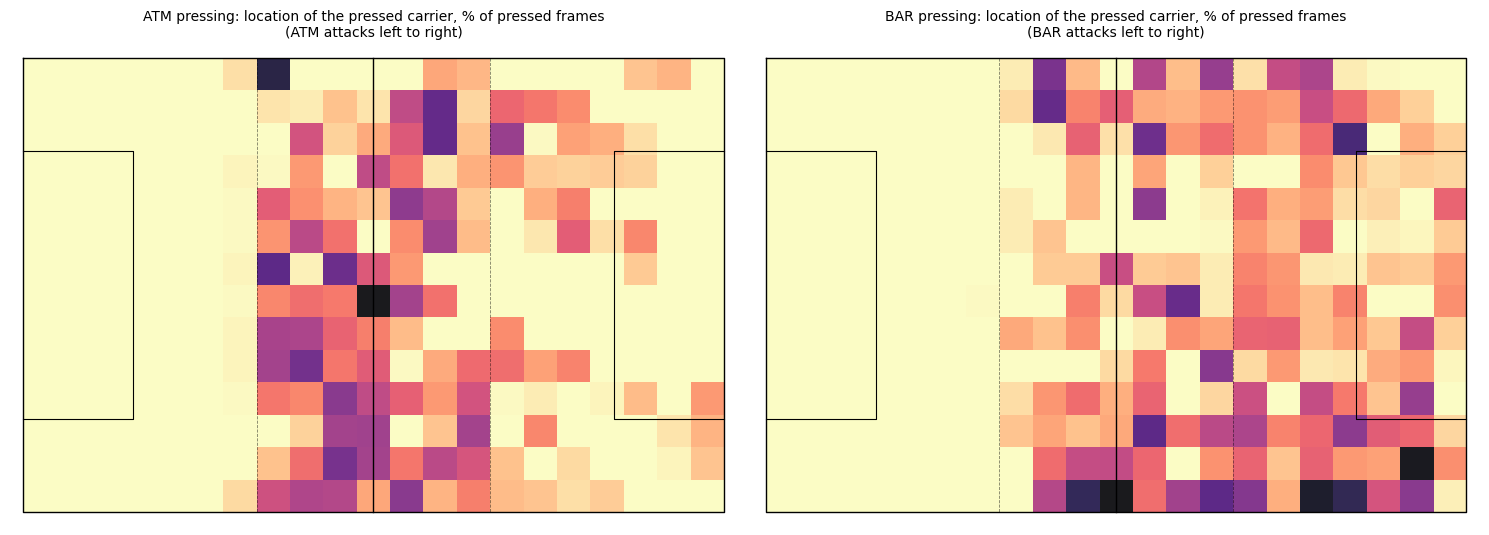


saved to C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\new\press\buildup_output\shape_press_stats


In [4]:
# ================================================================== 4. Press zone and who presses
# Zones are in the DEFENDING team's own frame: it attacks towards +x. "high press" = the pressed carrier is in the defending team's attacking third
# (i.e. in the pressed team's own third); "low block" = in the defending team's own third. Channels use neutral names (y_low / centre / y_high)
# until you confirm which side is left on the video.
inb = np.zeros(int(frames.frame_idx.max()) + 2, bool)                  # frames that belong to a build-up
for b in buildups.itertuples():
    inb[b.start_frame:b.end_frame + 1] = True
fp = frames.drop_duplicates("frame_idx").sort_values("frame_idx")
fp = fp[inb[fp.frame_idx.to_numpy()] & fp.x_att.notna()].copy()
fp["poss_team"] = fp.poss_team.astype(int); fp["def_team_name"] = (1 - fp.poss_team).map(TEAM_NAMES)
fp["x_def"], fp["y_def"] = L - fp.x_att, W - fp.y_att                  # target location in the defender's own frame
fp["zone"] = np.select([fp.x_def < L / 3, fp.x_def < 2 * L / 3], ["low block", "mid block"], "high press")
fp["channel"] = np.select([fp.y_def < W / 3, fp.y_def > 2 * W / 3], ["y_low", "y_high"], "centre")
fp["under_pressure"] = fp.under_pressure.astype(bool)
ZONES = ["low block", "mid block", "high press"]

pf_ = fp[fp.under_pressure]
print(f"{len(fp):,} build-up frames with a located target, {len(pf_):,} of them under pressure ({len(pf_) / len(fp) * 100:.0f}%)\n")

# ------------------------------------------------------------------ A. where does the press happen
print("A. share of each team's pressed frames by zone, % (where it presses the ball):")
zs = pf_.groupby("def_team_name")["zone"].value_counts(normalize=True).mul(100).round(1).unstack(fill_value=0).reindex(columns=ZONES, fill_value=0)
print(zs.to_string())
print("\n   press rate by zone, % of the opponent's build-up frames in that zone that were under pressure:")
pr_zone = fp.groupby(["def_team_name", "zone"])["under_pressure"].mean().mul(100).round(1).unstack().reindex(columns=ZONES)
print(pr_zone.to_string())
print("\n   zone x channel, share of the team's pressed frames, %:")
zc = pf_.groupby(["def_team_name", "zone", "channel"]).size().div(pf_.groupby("def_team_name").size(), level=0).mul(100).round(1).unstack(fill_value=0)
print(zc.reindex(ZONES, level=1).to_string())

# ------------------------------------------------------------------ B. pressing episodes: where does each one START
ep = []
for sid, g in fp.groupby("spell_id"):
    fr_, up_ = g.frame_idx.to_numpy(), g.under_pressure.to_numpy()
    for s, e in bool_runs(up_, fr_):
        ep.append(dict(def_team_name=g.def_team_name.iat[0], zone=g.zone.iat[s], channel=g.channel.iat[s], dur_s=(e - s + 1) / FPS))
ep = pd.DataFrame(ep)
print(f"\nB. {len(ep)} pressing episodes (runs of 'under pressure'); zone where each episode starts, count:")
print(ep.groupby(["def_team_name", "zone"]).size().unstack(fill_value=0).reindex(columns=ZONES, fill_value=0).to_string())
print("   median episode length (s):", ep.groupby("def_team_name")["dur_s"].median().round(1).to_dict())

# ------------------------------------------------------------------ C. who presses (INFERRED positions)
LINE = {"LB": "defenders", "CB": "defenders", "RB": "defenders", "LM": "midfielders", "CM": "midfielders", "RM": "midfielders",
        "LW": "forwards", "ST": "forwards", "RW": "forwards"}
dm = defenders[defenders.is_press.astype(bool)]
dm = dm[inb[np.clip(dm.frame_idx.to_numpy(), 0, len(inb) - 1)]].merge(roster[["track_id", "team", "name", "number", "position"]], on="track_id", how="left")
dm["line"] = dm.position.map(LINE).fillna("unknown"); dm["team_name"] = dm.team.map(TEAM_NAMES)
print(f"\nC. presser-frames: {len(dm):,} (one row per pressing defender per frame)")
print("   share by line, % of the team's presser-frames (lines come from INFERRED positions):")
print(dm.groupby("team_name")["line"].value_counts(normalize=True).mul(100).round(1).unstack(fill_value=0).to_string())
top = (dm.groupby(["team_name", "number", "name"]).size().div(FPS).round(1).rename("pressing_seconds").reset_index()
         .sort_values(["team_name", "pressing_seconds"], ascending=[True, False]).groupby("team_name").head(5))
print("\n   most pressing seconds per player (a player can be one of several pressers in the same frame):")
print(top.to_string(index=False))

# ------------------------------------------------------------------ D. heatmaps of the press location, defending team attacks left to right
def draw_pitch(ax):
    ax.plot([0, L, L, 0, 0], [0, 0, W, W, 0], "k", lw=1); ax.plot([L / 2] * 2, [0, W], "k", lw=1)
    for x_ in (L / 3, 2 * L / 3):
        ax.plot([x_, x_], [0, W], color="k", lw=0.6, ls="--", alpha=0.5)
    for x0, sgn in ((0, 1), (L, -1)):
        ax.plot([x0, x0 + sgn * 16.5, x0 + sgn * 16.5, x0], [W / 2 - 20.15, W / 2 - 20.15, W / 2 + 20.15, W / 2 + 20.15], "k", lw=0.8)
    ax.set_xlim(-2, L + 2); ax.set_ylim(W + 2, -2); ax.set_aspect("equal"); ax.axis("off")

teams = sorted(pf_.def_team_name.unique())
fig, axes = plt.subplots(1, len(teams), figsize=(7.5 * len(teams), 5.2))
for ax, tn in zip(np.atleast_1d(axes), teams):
    g = pf_[pf_.def_team_name == tn]
    h, xe, ye = np.histogram2d(g.x_def, g.y_def, bins=[21, 14], range=[[0, L], [0, W]])
    ax.imshow((h / h.sum() * 100).T, origin="upper", extent=[0, L, W, 0], cmap="magma_r", aspect="equal", alpha=0.9)
    draw_pitch(ax); ax.set_title(f"{tn} pressing: location of the pressed carrier, % of pressed frames\n({tn} attacks left to right)", fontsize=10)
plt.tight_layout(); png = STATS_DIR / "press_zone_heatmap.png"; plt.savefig(png, dpi=110); plt.show()

zs.to_csv(STATS_DIR / "press_zone_share.csv"); pr_zone.to_csv(STATS_DIR / "press_rate_by_zone.csv"); zc.to_csv(STATS_DIR / "press_zone_by_channel.csv")
dm.groupby("team_name")["line"].value_counts(normalize=True).rename("share").to_csv(STATS_DIR / "pressers_by_line.csv"); top.to_csv(STATS_DIR / "top_pressers.csv", index=False)
print("\nsaved to", STATS_DIR)
